In [1]:
import random
import copy
import math
import multiprocessing
import numpy as np
from deap import base, tools, creator, algorithms
from dataset_2 import requests, staff, supplies
from functions import build_gene, cxTwoPointCustomMate, mutCustom, optimize_route, distance, print_solution, get_staff_for_request
from elitism import eaSimpleWithElitism
import matplotlib.pyplot as plt


"""
Requirement:
    1. Delivery emergency supplies to locations
    2. Schedule medical personnel to visit locations
    
Chromosome:
 ________________Request ID # 1______________, _____...
[[VehID, StaffID, DeliveryDay, StaffVisitDay], [......]]
"""

DAYS = 20
VEHICLE_CAPACITY = 15
VEHICLE_MAX_DISTANCE = 400
VEHICLE_DISTANCE_COST = 40
VEHICLE_DAY_COST = 300
VEHICLE_FIXED_COST = 12000

STAFF_DISTANCE_COST = 25
STAFF_DAY_COST = 200
STAFF_FIXED_COST = 6000
STAFF_WORK_THRESHOLD = 5

MAX_VEHICLES = 5

NUM_RUNS = 10


# Per-iteration cost history — replace with your actual recorded lists
convergence = {
    "GA":      [],
    "ACO":     [],
    "NSGA-II": [],
    "SA":      [],
}

best_ga = None
best_aco = None
best_nsga = None
best_sa = None

GENETIC ALGORITHM (GA) - BASELINE

gen	nevals	min   	mean  
0  	660   	780324	918150
1  	598   	728410	866153
2  	590   	644388	808182
3  	616   	625490	750873
4  	622   	590016	701581
5  	602   	549564	661570
6  	601   	509715	628597
7  	611   	490607	599065
8  	611   	471867	572239
9  	599   	471867	549898
10 	604   	448830	530787
11 	602   	436986	514870
12 	607   	414571	499321
13 	603   	412646	484208
14 	611   	401865	473337
15 	616   	401238	462924
16 	627   	385976	452298
17 	580   	382293	441892
18 	601   	374211	433427
19 	610   	374211	425932
20 	605   	372295	417239
21 	614   	357676	412608
22 	610   	352930	405696
23 	617   	344920	400199
24 	613   	335532	397143
25 	620   	335532	391517
26 	623   	335532	387652
27 	611   	335532	383429
28 	589   	334863	379511
29 	619   	331410	376011
30 	628   	329320	376437
31 	608   	327716	372322
32 	616   	327248	369848
33 	605   	325495	366672
34 	605   	321809	363298
35 	604   	320320	363238
36 	609   	320320	363986
37 	602   	316796	360962
38 	624   	311326	358650


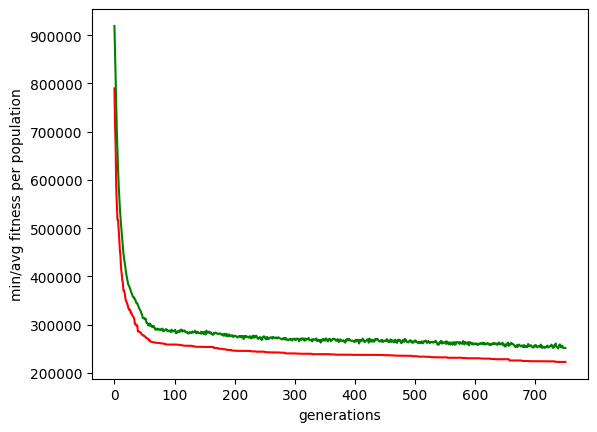

In [3]:
POP_SIZE = 660
NGEN = 750
CXPB = 0.9
MUTPB = 0.3
INDPB = 1/4


# FITNESS
def fitness(individual):
    total_v_cost = 0
    total_v_dist = 0
    total_s_cost = 0
    total_s_dist = 0
    total_penalties = 0
    total_delay_penalties = 0

    vehicle_usage = set()
    vehicles_per_day = {}
    vehicle_plan = {}

    staff_usage = set()
    staff_work_days = {s_id: set() for s_id in staff} # [] => set()
    staff_plan = {}

    for id, gene in enumerate(individual):
        r_id = id + 1
        v_id, s_id, dd, svd = gene

        request = requests[r_id]
        medical_staff = staff[s_id]

        staff_plan.setdefault((svd, s_id), []).append(r_id)
        vehicle_plan.setdefault((dd, v_id), []).append(r_id)
        vehicles_per_day.setdefault(dd, set()).add(v_id)
        staff_work_days[s_id].add(svd)

        # 1. PENALTY: Although staff wil match requested speciality, but we will still add condition just in case
        if medical_staff[request['specialty_needed']] != 1:
            total_penalties += 5000
        
        # 2. PENALTY: Check if delivery day (dd) is within the delivery range otherwise penalty
        if dd > request['day_end']:
            days_to_penalise = dd - request['day_end']
            penalty = (days_to_penalise * supplies[request['supply_id']]['penalty_per_day'] * supplies[request['supply_id']]['criticality'])
            total_penalties += penalty
            total_delay_penalties += penalty

        # PENALTY: Delivery cannot happen before the start day
        if dd < request['day_start']:
            total_penalties += 5000
    
        # PENALTY: Staff can only visit after the supply has been delivered i.e. on same day or the next day. 
        # However, if that next day should be within the request's start and end day.
        if svd < dd or svd > dd + 1:
            total_penalties += 5000
            total_delay_penalties += 5000
        if svd > request['day_end']:
            total_penalties += 7000
            total_delay_penalties += 7000


    daily_vehicle_costs = {}
    # VEHICLE ROUTING
    for (day, v_id), req_list in vehicle_plan.items():
        route = optimize_route(req_list=req_list, requests=requests)

        curr_v_load, curr_v_dist, curr_loc = 0, 0, 1
        vehicle_usage.add(v_id)

        for r_id in route:
            req = requests[r_id]
            loc_id = req['location_id']

            supply_load = supplies[req['supply_id']]['size'] * req['quantity']

            # calculate distance to X and from X back to Depot 1
            dist_to = distance(curr_loc, loc_id)

            #Exclude return distance
            # dist_back = distance(loc_id, 1)

            # if the load increases the capacity then return to depot
            if curr_v_load + supply_load > VEHICLE_CAPACITY:
                # Exclude MID Route return distance to depot 1
                # curr_v_dist += distance(curr_loc, 1)
                curr_v_load, curr_loc = 0, 1 # reset

                dist_to = distance(curr_loc, loc_id) # re calculate distance from 1 to target
                total_penalties += 4000

            curr_v_dist += dist_to
            curr_v_load += supply_load
            curr_loc = loc_id

            # PENALTY: if single request exceeds the capacity
            if supply_load > VEHICLE_CAPACITY:
                total_penalties += 5000

        # Exclude distance for Depot
        # curr_v_dist += distance(curr_loc, 1)

        # PENALTY: daily distance limit
        if curr_v_dist > VEHICLE_MAX_DISTANCE:
            total_penalties += 5000

        # COST: VEHICLE COSTS
        v_standard_cost = VEHICLE_DAY_COST + (curr_v_dist * VEHICLE_DISTANCE_COST)
        daily_vehicle_costs[(day, v_id)] = v_standard_cost

        total_v_dist += curr_v_dist
        # COST: VEHICLE COSTS
        total_v_cost += v_standard_cost

    # COST/PENALTY: VEHICLE DAILY LIMIT PENALTY
    for day, vset in vehicles_per_day.items():
        if len(vset) > MAX_VEHICLES:
            v_list = list(vset)
            v_list.sort(key=lambda x: daily_vehicle_costs[(day, x)], reverse=True)

            extra_vehicles = len(vset) - MAX_VEHICLES
            for i in range(extra_vehicles):
                veh_id = v_list[i]
                total_v_cost += daily_vehicle_costs[(day, veh_id)]

    # COST: VEHICLE FIXED COST
    total_v_cost += (len(vehicle_usage) * VEHICLE_FIXED_COST)


    # STAFF ROUTING
    for (day, s_id), req_list in staff_plan.items():
        medical_staff = staff[s_id]
        home_loc = medical_staff["location_id"]

        curr_s_loc, curr_s_dist = home_loc, 0

        staff_usage.add(s_id)

        route = optimize_route(req_list, requests)

        # PENALTY: Staff should not exceed allowed patients visits per day
        if len(route) > medical_staff["max_patients_per_day"]:
            total_penalties += 5000

        for r_id in route:
            loc = requests[r_id]["location_id"]
            dist_to = distance(curr_s_loc, loc)
            curr_s_loc = loc

            curr_s_dist += dist_to

        # Staff returns to home location, calculate the distance
        # Excluding the return distance
        # dist_back = distance(curr_s_loc, home_loc)
        # curr_s_dist += dist_back


        # PENALTY: Staff should not exceed max distance per day
        if curr_s_dist > medical_staff['max_distance']:
            total_penalties += 5000


        total_s_dist += curr_s_dist
        # COST: Distance cost
        total_s_cost += STAFF_DAY_COST + (curr_s_dist * STAFF_DISTANCE_COST)

    # COST: Fixed cost for the active staff
    total_s_cost += (len(staff_usage) * STAFF_FIXED_COST)

    # PENALTY: Staff must not work on 6th day if they have been working for 5 days consecutively.
    for s_id, days in staff_work_days.items():
        sorted_days = sorted(list(days))
        streak = 1

        for i in range(1, len(sorted_days)):
            if sorted_days[i] == sorted_days[i-1] + 1:
                streak += 1
                if streak > 5:
                    total_penalties += 10000
            else:
                streak = 1

    total_cost = total_v_cost + total_s_cost + total_penalties 

    individual.metrics = {
        "vehicle_distance": total_v_dist,
        "vehicle_usage_days": vehicles_per_day,
        "vehicle_usage": vehicle_usage,
        "staff_distance": total_s_dist,
        "vehicle_cost": total_v_cost,
        "staff_cost": total_s_cost,
        "staff_usage": staff_usage,
        "staff_usage_days": staff_work_days,
        "penalties": total_penalties,
        "delay_penalties": total_delay_penalties,
        "total_cost": total_cost
    }

    return (total_cost,)


def create_individual():
    return [build_gene(requests[r_id], DAYS) for r_id in requests]

toolbox = base.Toolbox()
creator.create("fitnessMin", base=base.Fitness, weights=(-1.0,))
creator.create("Individual", list, fitness=creator.fitnessMin)

toolbox.register("individual", tools.initIterate, creator.Individual, create_individual)
toolbox.register("createPopulation", tools.initRepeat, list, toolbox.individual)

toolbox.register("evaluate", fitness)
toolbox.register("mate", cxTwoPointCustomMate)
toolbox.register(
    "mutate", mutCustom, indpb=INDPB, DAYS=DAYS, requests=requests, staff=staff
)
toolbox.register("select", tools.selTournament, tournsize=3)

stats = tools.Statistics(lambda individual: individual.fitness.values[0])
stats.register("min", np.min)
stats.register("mean", np.mean)

all_times_best = None
all_times_worst = None
avg_cost = 0
log = None

def run_ga_iteration(run_id):
    random.seed() 
    
    population = toolbox.createPopulation(POP_SIZE)
    hall_of_fame = tools.HallOfFame(5)

    final_population, log = eaSimpleWithElitism(
        population=population,
        halloffame=hall_of_fame,
        stats=stats,
        toolbox=toolbox,
        ngen=NGEN,
        cxpb=CXPB,
        mutpb=MUTPB,
        verbose=((run_id + 1) == NUM_RUNS)
    )
    
    return hall_of_fame[0], log


if __name__ == '__main__':
    try:
        multiprocessing.set_start_method('fork', force=True)
    except RuntimeError:
        pass
    
    with multiprocessing.Pool() as pool:
        best_individuals = pool.map(run_ga_iteration, range(NUM_RUNS))
        
    for best, logbook in best_individuals:
        cost = best.metrics['total_cost']

        avg_cost += (cost - best.metrics['penalties'])
        
        if all_times_worst is None or cost > all_times_worst.metrics['total_cost']:
            all_times_worst = best
            
        if all_times_best is None or cost < all_times_best.metrics['total_cost']:
            all_times_best = best
            log = logbook

    all_times_best.metrics['total_worst'] = all_times_worst.metrics['total_cost'] - all_times_worst.metrics['penalties']
    all_times_best.metrics['avg_cost'] = avg_cost/NUM_RUNS
    best_ga = all_times_best
    print_solution(all_times_best, requests, DAYS, "best_ga.txt")

    convergence["GA"] = log.select("min")

    plt.plot(log.select("min"), color="red")
    plt.plot(log.select("mean"), color="green")
    plt.xlabel("generations")
    plt.ylabel("min/avg fitness per population")
    plt.show()


NSGA-II - MULTI OBJECTIVE

gen	nevals	min   
0  	0     	820336
1  	660   	733490
2  	660   	651571
3  	660   	651571
4  	660   	650894
5  	660   	600014
6  	660   	600014
7  	660   	586068
8  	660   	567803
9  	660   	561412
10 	660   	534899
11 	660   	534653
12 	660   	513994
13 	660   	513994
14 	660   	513994
15 	660   	495061
16 	660   	490005
17 	660   	467595
18 	660   	467595
19 	660   	467595
20 	660   	467346
21 	660   	455591
22 	660   	451098
23 	660   	440941
24 	660   	436612
25 	660   	436612
26 	660   	424743
27 	660   	419085
28 	660   	413393
29 	660   	413393
30 	660   	409967
31 	660   	409967
32 	660   	393197
33 	660   	393197
34 	660   	392413
35 	660   	387061
36 	660   	387061
37 	660   	387061
38 	660   	385058
39 	660   	384793
40 	660   	375616
41 	660   	375169
42 	660   	368710
43 	660   	365690
44 	660   	365690
45 	660   	363106
46 	660   	363106
47 	660   	363106
48 	660   	361088
49 	660   	357199
50 	660   	351222
51 	660   	351222
52 	660   	350428
53 	660   	337618
54 	660   

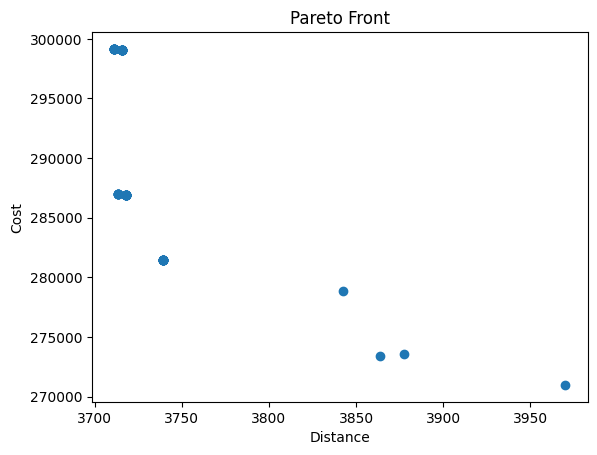

In [ ]:
# POP_SIZE = 460
# NGEN = 400
POP_SIZE = 660
NGEN = 750
CXPB = 0.8
MUTPB = 0.2
INDPB = 0.3


# MULTI-OBJECTIVE FITNESS
def fitness(individual):
    total_v_cost = 0
    total_v_dist = 0
    total_s_cost = 0
    total_s_dist = 0
    total_penalties = 0
    total_delay_penalties = 0

    vehicle_usage = set()
    vehicles_per_day = {}
    vehicle_plan = {}

    staff_usage = set()
    staff_work_days = {s_id: set() for s_id in staff} # [] => set()
    staff_plan = {}

    for id, gene in enumerate(individual):
        r_id = id + 1
        v_id, s_id, dd, svd = gene

        request = requests[r_id]
        medical_staff = staff[s_id]

        staff_plan.setdefault((svd, s_id), []).append(r_id)
        vehicle_plan.setdefault((dd, v_id), []).append(r_id)
        vehicles_per_day.setdefault(dd, set()).add(v_id)
        staff_work_days[s_id].add(svd) # NEW

        # 1. PENALTY: Although staff wil match requested speciality, but we will still add condition just in case
        if medical_staff[request['specialty_needed']] != 1:
            total_penalties += 5000
        
        # 2. PENALTY: Check if delivery day (dd) is within the delivery range otherwise penalty
        if dd > request['day_end']:
            days_to_penalise = dd - request['day_end']
            penalty = (days_to_penalise * supplies[request['supply_id']]['penalty_per_day'] * supplies[request['supply_id']]['criticality'])
            total_penalties += penalty
            total_delay_penalties += penalty

        # PENALTY: Delivery cannot happen before the start day
        if dd < request['day_start']:
            total_penalties += 5000
    
        # PENALTY: Staff can only visit after the supply has been delivered i.e. on same day or the next day.
        if svd < dd or svd > dd + 1:
            total_penalties += 5000
            total_delay_penalties += 5000
        if svd > request['day_end']:
            total_penalties += 7000
            total_delay_penalties += 7000


    daily_vehicle_costs = {}
    # VEHICLE ROUTING
    for (day, v_id), req_list in vehicle_plan.items():
        route = optimize_route(req_list=req_list, requests=requests)

        curr_v_load, curr_v_dist, curr_loc = 0, 0, 1
        vehicle_usage.add(v_id)

        for r_id in route:
            req = requests[r_id]
            loc_id = req['location_id']

            supply_load = supplies[req['supply_id']]['size'] * req['quantity']

            # calculate distance to X and from X back to Depot 1
            dist_to = distance(curr_loc, loc_id)

            #Exclude return distance
            # dist_back = distance(loc_id, 1)

            # if the load increases the capacity then return to depot
            if curr_v_load + supply_load > VEHICLE_CAPACITY:
                # Exclude MID Route return distance to depot 1
                # curr_v_dist += distance(curr_loc, 1)
                curr_v_load, curr_loc = 0, 1 # reset

                dist_to = distance(curr_loc, loc_id) # re calculate distance from 1 to target
                total_penalties += 3000
                # continue

            curr_v_dist += dist_to
            curr_v_load += supply_load
            curr_loc = loc_id

            # PENALTY: if single request exceeds the capacity
            if supply_load > VEHICLE_CAPACITY:
                total_penalties += 5000

        # Exclude distance for Depot
        # curr_v_dist += distance(curr_loc, 1)

        # PENALTY: daily distance limit
        if curr_v_dist > VEHICLE_MAX_DISTANCE:
            total_penalties += 5000

        # COST: VEHICLE COSTS
        v_standard_cost = VEHICLE_DAY_COST + (curr_v_dist * VEHICLE_DISTANCE_COST)
        daily_vehicle_costs[(day, v_id)] = v_standard_cost

        total_v_dist += curr_v_dist
        # COST: VEHICLE COSTS
        total_v_cost += v_standard_cost

    # COST/PENALTY: VEHICLE DAILY LIMIT PENALTY
    for day, vset in vehicles_per_day.items():
        if len(vset) > MAX_VEHICLES:
            v_list = list(vset)
            v_list.sort(key=lambda x: daily_vehicle_costs[(day, x)], reverse=True)

            extra_vehicles = len(vset) - MAX_VEHICLES
            for i in range(extra_vehicles):
                veh_id = v_list[i]
                total_v_cost += daily_vehicle_costs[(day, veh_id)]

    # COST: VEHICLE FIXED COST
    total_v_cost += (len(vehicle_usage) * VEHICLE_FIXED_COST)


    # STAFF ROUTING
    for (day, s_id), req_list in staff_plan.items():
        medical_staff = staff[s_id]
        home_loc = medical_staff["location_id"]

        curr_s_loc, curr_s_dist = home_loc, 0

        staff_usage.add(s_id)

        route = optimize_route(req_list, requests)

        # PENALTY: Staff should not exceed allowed patients visits per day
        if len(route) > medical_staff["max_patients_per_day"]:
            total_penalties += 5000

        for r_id in route:
            loc = requests[r_id]["location_id"]
            dist_to = distance(curr_s_loc, loc)
            curr_s_loc = loc

            curr_s_dist += dist_to

        # Staff returns to home location, calculate the distance
        # Excluding the return distance
        # dist_back = distance(curr_s_loc, home_loc)
        # curr_s_dist += dist_back


        # PENALTY: Staff should not exceed max distance per day
        if curr_s_dist > medical_staff['max_distance']:
            total_penalties += 5000


        total_s_dist += curr_s_dist
        # COST: Distance cost
        total_s_cost += STAFF_DAY_COST + (curr_s_dist * STAFF_DISTANCE_COST)

    # COST: Fixed cost for the active staff
    total_s_cost += (len(staff_usage) * STAFF_FIXED_COST)

    # PENALTY: Staff must not work on 6th day if they have been working for 5 days consecutively.
    for s_id, days in staff_work_days.items():
        sorted_days = sorted(list(days))
        streak = 1

        for i in range(1, len(sorted_days)):
            if sorted_days[i] == sorted_days[i-1] + 1:
                streak += 1
                if streak > 5:
                    total_penalties += 10000
            else:
                streak = 1

    total_cost = total_v_cost + total_s_cost + total_penalties 

    individual.metrics = {
        "vehicle_distance": total_v_dist,
        "vehicle_usage_days": vehicles_per_day,
        "vehicle_usage": vehicle_usage,
        "staff_distance": total_s_dist,
        "vehicle_cost": total_v_cost,
        "staff_cost": total_s_cost,
        "staff_usage": staff_usage,
        "staff_usage_days": staff_work_days,
        "penalties": total_penalties,
        "delay_penalties": total_delay_penalties,
        "total_cost": total_cost
    }

    # ================= NSGA-II OBJECTIVES =================
    return (
        total_cost,  # Obj 1: Cost
        total_v_dist + total_s_dist,  # Obj 2: Distance
        total_penalties,
    )

# INITIALIZATION
def create_individual():
    return [build_gene(requests[r_id], DAYS) for r_id in requests]

creator.create("FitnessMulti", base.Fitness, weights=(-1.0, -1.0, -1.0))
creator.create("Individual", list, fitness=creator.FitnessMulti)

toolbox = base.Toolbox()
toolbox.register("individual", tools.initIterate, creator.Individual, create_individual)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

toolbox.register("evaluate", fitness)
toolbox.register("mate", cxTwoPointCustomMate)
toolbox.register("mutate", mutCustom, indpb=INDPB, DAYS=DAYS, requests=requests, staff=staff)
toolbox.register("select", tools.selNSGA2)

stats = tools.Statistics(lambda individual: individual.fitness.values[0])
stats.register("min", np.min)

# NSGA-II LOOP
def run_nsga2(run_id):
    random.seed()
    population = toolbox.population(n=POP_SIZE)

    invalid_ind = [ind for ind in population if not ind.fitness.valid]
    fitnesses = toolbox.map(toolbox.evaluate, invalid_ind)
    for ind, fit in zip(invalid_ind, fitnesses):
        ind.fitness.values = fit

    population = toolbox.select(population, len(population))
    hof = tools.ParetoFront()
    final_population, logbook = algorithms.eaMuPlusLambda(
        population, 
        toolbox, 
        mu=POP_SIZE, 
        lambda_=POP_SIZE, 
        cxpb=CXPB, 
        mutpb=MUTPB, 
        ngen=NGEN, 
        stats=stats,
        halloffame=hof,
        verbose=((run_id + 1) == NUM_RUNS)
    )
    history = logbook.select("min")
    return hof, history


if __name__ == '__main__':
    all_runs_results = []
    best_nsga_cost = float('inf')
    nsga2_history = None
    massive_combined_population = []
    
    try:
        multiprocessing.set_start_method('fork', force=True)
    except RuntimeError:
        pass

    with multiprocessing.Pool() as pool:
        all_runs_results = pool.map(run_nsga2, range(NUM_RUNS))

    for final_pop, history in all_runs_results:
        massive_combined_population.extend(final_pop)
 
    # Extract Pareto Front
    pareto_front = tools.sortNondominated(massive_combined_population, len(massive_combined_population), first_front_only=True)[0]

    print(f"\nTotal Pareto Solutions: {len(pareto_front)}")

    best_nsga = min(pareto_front, key=lambda ind: ind.fitness.values[0] - ind.fitness.values[2])

    for final_pop, log in all_runs_results:
        if best_nsga in final_pop:
            convergence["NSGA-II"] = log
            break

    
    print_solution(best_nsga, requests, DAYS, "best_nsga.txt")

    # VISUALIZATION
    cost = [ind.fitness.values[0] - ind.fitness.values[2] for ind in pareto_front]
    dist = [ind.fitness.values[1] for ind in pareto_front]

    plt.scatter(dist, cost)
    plt.xlabel("Distance")
    plt.ylabel("Cost")
    plt.title("Pareto Front")
    plt.show()

ANT COLONY OPTIMZATION (ACO)

Starting Ant Colony Optimization...
Launching 10 parallel ACO runs...
Gen  10 | Best Cost: 381019 | Mean Cost: 407311 | Penalties: 9400
Gen  10 | Best Cost: 384604 | Mean Cost: 407164 | Penalties: 12400
Gen  10 | Best Cost: 380983 | Mean Cost: 407560 | Penalties: 9400
Gen  10 | Best Cost: 378922 | Mean Cost: 407494 | Penalties: 9950
Gen  10 | Best Cost: 375861 | Mean Cost: 406899 | Penalties: 8000
Gen  10 | Best Cost: 370215 | Mean Cost: 407162 | Penalties: 4400
Gen  10 | Best Cost: 378998 | Mean Cost: 408378 | Penalties: 8000
Gen  10 | Best Cost: 380378 | Mean Cost: 407609 | Penalties: 5400
Gen  10 | Best Cost: 381698 | Mean Cost: 408400 | Penalties: 11400
Gen  10 | Best Cost: 381301 | Mean Cost: 407164 | Penalties: 12200
Gen  20 | Best Cost: 381004 | Mean Cost: 406600 | Penalties: 10000
Gen  20 | Best Cost: 380983 | Mean Cost: 407367 | Penalties: 9400
Gen  20 | Best Cost: 379306 | Mean Cost: 406779 | Penalties: 8400
Gen  20 | Best Cost: 381301 | Mean Cost: 407866 | Penalties: 12200
G

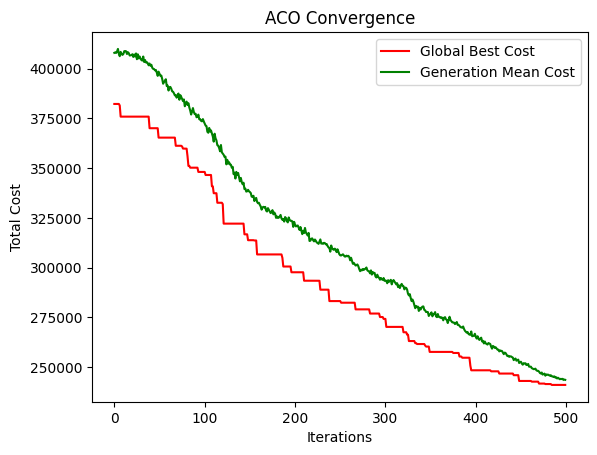

In [2]:
NUM_ANTS = 75
ITERATIONS = 500
EVAPORATION_RATE = 0.1758445017408108
Q = 13294.184088858867  # Pheromone deposit factor (scaled to your high costs)
ALPHA = 0.6839026392514785  # Pheromone importance
BETA = 1.9990941123903003  # Heuristic importance


search_space = {}

for r_id, req in requests.items():
    valid_choices = []
    # Only consider staff that actually have the required specialty (avoids 500 penalty)
    possible_staff = [
        s_id for s_id, s_data in staff.items() if s_data[req["specialty_needed"]] == 1
    ]

    for v_id in range(1, MAX_VEHICLES + 1):
        for s_id in possible_staff:
            # Delivery day: from allowed start to end of schedule
            for dd in range(req["day_start"], DAYS + 1):
                # Staff visit must be on the delivery day or the day after (avoids 300 penalty)
                for svd in range(dd, min(dd + 2, DAYS + 1)):

                    # Heuristic: We want to heavily prefer delivery days that don't incur penalties
                    delay = max(0, dd - req["day_end"])
                    delay_penalty = (
                        delay
                        * supplies[req["supply_id"]]["penalty_per_day"]
                        * supplies[req["supply_id"]]["criticality"]
                    )

                    # Inverse of penalty (add 1 to avoid division by zero).
                    # If penalty is 0, heuristic is 1.0. If penalty is high, heuristic is near 0.
                    heuristic_value = 1.0 / (1.0 + delay_penalty)

                    valid_choices.append(
                        {"tuple": (v_id, s_id, dd, svd), "heuristic": heuristic_value}
                    )

    search_space[r_id] = valid_choices

# Initialize Pheromones to 1.0 for all valid choices
pheromones = {
    r_id: {choice["tuple"]: 1.0 for choice in choices}
    for r_id, choices in search_space.items()
}


class AntSolution:
    def __init__(self, gene_list):
        self.gene_list = gene_list
        self.metrics = {}
        self.total_cost = 0

    # Add this method so functions.py can loop over it!
    def __iter__(self):
        return iter(self.gene_list)


def fitness(individual):
    total_v_cost = 0
    total_v_dist = 0
    total_s_cost = 0
    total_s_dist = 0
    total_penalties = 0
    total_delay_penalties = 0

    vehicle_usage = set()
    vehicles_per_day = {}
    vehicle_plan = {}

    staff_usage = set()
    staff_work_days = {s_id: set() for s_id in staff} # [] => set()
    staff_plan = {}

    for id, gene in enumerate(individual):
        r_id = id + 1
        v_id, s_id, dd, svd = gene

        request = requests[r_id]
        medical_staff = staff[s_id]

        staff_plan.setdefault((svd, s_id), []).append(r_id)
        vehicle_plan.setdefault((dd, v_id), []).append(r_id)
        vehicles_per_day.setdefault(dd, set()).add(v_id)
        staff_work_days[s_id].add(svd) # NEW

        # 1. PENALTY: Although staff wil match requested speciality, but we will still add condition just in case
        if medical_staff[request['specialty_needed']] != 1:
            total_penalties += 500
        
        # 2. PENALTY: Check if delivery day (dd) is within the delivery range otherwise penalty
        if dd > request['day_end']:
            days_to_penalise = dd - request['day_end']
            penalty = (days_to_penalise * supplies[request['supply_id']]['penalty_per_day'] * supplies[request['supply_id']]['criticality'])
            total_penalties += penalty
            total_delay_penalties += penalty

        # PENALTY: Delivery cannot happen before the start day
        if dd < request['day_start']:
            total_penalties += 500
    
        # PENALTY: Staff can only visit after the supply has been delivered i.e. on same day or the next day.
        if svd < dd or svd > dd + 1:
            total_penalties += 800
        if svd > request['day_end']:
            total_penalties += 1000


    daily_vehicle_costs = {}
    # VEHICLE ROUTING
    for (day, v_id), req_list in vehicle_plan.items():
        route = optimize_route(req_list=req_list, requests=requests)

        curr_v_load, curr_v_dist, curr_loc = 0, 0, 1
        vehicle_usage.add(v_id)

        for r_id in route:
            req = requests[r_id]
            loc_id = req['location_id']

            supply_load = supplies[req['supply_id']]['size'] * req['quantity']

            # calculate distance to X and from X back to Depot 1
            dist_to = distance(curr_loc, loc_id)
            # dist_back = distance(loc_id, 1)

            # if the load increases the capacity then return to depot
            if curr_v_load + supply_load > VEHICLE_CAPACITY:
                # curr_v_dist += distance(curr_loc, 1)
                curr_v_load, curr_loc = 0, 1 # reset

                dist_to = distance(curr_loc, loc_id) # re calculate distance from 1 to target
                total_penalties += 1000
                # continue

            curr_v_dist += dist_to
            curr_v_load += supply_load
            curr_loc = loc_id

            # PENALTY: if single request exceeds the capacity
            if supply_load > VEHICLE_CAPACITY:
                total_penalties += 2000

        # Include distance for Depot
        # curr_v_dist += distance(curr_loc, 1)

        # PENALTY: daily distance limit
        if curr_v_dist > VEHICLE_MAX_DISTANCE:
            total_penalties += 300

        # COST: VEHICLE COSTS
        v_standard_cost = VEHICLE_DAY_COST + (curr_v_dist * VEHICLE_DISTANCE_COST)
        daily_vehicle_costs[(day, v_id)] = v_standard_cost

        total_v_dist += curr_v_dist
        # COST: VEHICLE COSTS
        total_v_cost += v_standard_cost

    # COST/PENALTY: VEHICLE DAILY LIMIT PENALTY
    for day, vset in vehicles_per_day.items():
        if len(vset) > MAX_VEHICLES:
            v_list = list(vset)
            v_list.sort(key=lambda x: daily_vehicle_costs[(day, x)], reverse=True)

            extra_vehicles = len(vset) - MAX_VEHICLES
            for i in range(extra_vehicles):
                veh_id = v_list[i]
                total_v_cost += daily_vehicle_costs[(day, veh_id)]

    # COST: VEHICLE FIXED COST
    total_v_cost += (len(vehicle_usage) * VEHICLE_FIXED_COST)


    # STAFF ROUTING
    for (day, s_id), req_list in staff_plan.items():
        medical_staff = staff[s_id]
        home_loc = medical_staff["location_id"]

        curr_s_loc, curr_s_dist = home_loc, 0

        staff_usage.add(s_id)

        route = optimize_route(req_list, requests)

        # PENALTY: Staff should not exceed allowed patients visits per day
        if len(route) > medical_staff["max_patients_per_day"]:
            total_penalties += 2000

        for r_id in route:
            loc = requests[r_id]["location_id"]
            dist_to = distance(curr_s_loc, loc)
            curr_s_loc = loc

            curr_s_dist += dist_to

        # Staff returns to home location, calculate the distance
        # dist_back = distance(curr_s_loc, home_loc)
        # curr_s_dist += dist_back


        # PENALTY: Staff should not exceed max distance per day
        if curr_s_dist > medical_staff['max_distance']:
            total_penalties += 400


        total_s_dist += curr_s_dist
        # COST: Distance cost
        total_s_cost += STAFF_DAY_COST + (curr_s_dist * STAFF_DISTANCE_COST)

    # COST: Fixed cost for the active staff
    total_s_cost += (len(staff_usage) * STAFF_FIXED_COST)

    # PENALTY: Staff must not work on 6th day if they have been working for 5 days consecutively.
    for s_id, days in staff_work_days.items():
        sorted_days = sorted(list(days))
        streak = 1

        for i in range(1, len(sorted_days)):
            if sorted_days[i] == sorted_days[i-1] + 1:
                streak += 1
                if streak > 5:
                    total_penalties += 550
            else:
                streak = 1

    total_cost = total_v_cost + total_s_cost + total_penalties 

    individual.metrics = {
        "vehicle_distance": total_v_dist,
        "vehicle_usage_days": vehicles_per_day,
        "vehicle_usage": vehicle_usage,
        "staff_distance": total_s_dist,
        "vehicle_cost": total_v_cost,
        "staff_cost": total_s_cost,
        "staff_usage": staff_usage,
        "staff_usage_days": staff_work_days,
        "penalties": total_penalties,
        "delay_penalties": total_delay_penalties,
        "total_cost": total_cost
    }
    individual.total_cost = total_cost

    return total_cost


# MAIN ACO ALGORITHM
print("Starting Ant Colony Optimization...")

def run_aco(run_id):
    np.random.seed()
    random.seed()

    global_best_ant = None
    history_best = []
    history_mean = []

    for iteration in range(ITERATIONS):
        colony = []
        iteration_costs = []

        # 1. Ants construct solutions
        for _ in range(NUM_ANTS):
            solution_genes = []

            for r_id in sorted(requests.keys()):
                choices = search_space[r_id]
                probabilities = []

                # Calculate probability for each choice
                for choice in choices:
                    tau = pheromones[r_id][choice["tuple"]]
                    eta = choice["heuristic"]
                    prob = (tau**ALPHA) * (eta**BETA)
                    probabilities.append(prob)

                # Normalize probabilities
                prob_sum = sum(probabilities)
                if prob_sum == 0:
                    probabilities = [1.0 / len(choices)] * len(choices)
                else:
                    probabilities = [p / prob_sum for p in probabilities]

                # Roulette wheel selection
                chosen_idx = np.random.choice(len(choices), p=probabilities)
                solution_genes.append(choices[chosen_idx]["tuple"])

            # Create ant and evaluate
            ant = AntSolution(solution_genes)
            cost = fitness(ant)
            colony.append(ant)
            iteration_costs.append(cost)

            # Track global best
            if global_best_ant is None or cost < global_best_ant.total_cost:
                global_best_ant = ant

        # 2. Pheromone Evaporation
        for r_id in requests.keys():
            for tpl in pheromones[r_id]:
                pheromones[r_id][tpl] *= 1.0 - EVAPORATION_RATE

        # 3. Pheromone Deposit (Elitist updating - only the best ants deposit)
        # Sort colony by cost (lowest is best)
        colony.sort(key=lambda x: x.total_cost)

        # Let top 10% of ants deposit pheromones
        top_ants = colony[: max(1, int(NUM_ANTS * 0.1))]

        for ant in top_ants:
            deposit_amount = Q / ant.total_cost
            for i, gene in enumerate(ant.gene_list):
                pheromones[i + 1][gene] += deposit_amount

        # Global Best deposits extra (Max-Min approach flavor)
        deposit_amount_best = (Q * 2) / global_best_ant.total_cost
        for i, gene in enumerate(global_best_ant.gene_list):
            pheromones[i + 1][gene] += deposit_amount_best

        # Logging
        mean_cost = np.mean(iteration_costs)
        history_best.append(global_best_ant.total_cost)
        history_mean.append(mean_cost)

        if (iteration + 1) % 10 == 0:
            print(
                f"Gen {iteration + 1:3d} | Best Cost: {global_best_ant.total_cost:.0f} | Mean Cost: {mean_cost:.0f} | Penalties: {global_best_ant.metrics['penalties']:.0f}"
            )

    return global_best_ant, history_best, history_mean


if __name__ == "__main__":
    all_time_best_ant = None
    history_mean_ant = None

    try:
        multiprocessing.set_start_method('fork', force=True)
    except RuntimeError:
        pass

    with multiprocessing.Pool() as pool:
        print(f"Launching {NUM_RUNS} parallel ACO runs...")
        results = pool.map(run_aco, range(NUM_RUNS))

    for i, (best_ant, history_best, history_mean) in enumerate(results):
        if all_time_best_ant is None or best_ant.total_cost < all_time_best_ant.total_cost:
            all_time_best_ant = best_ant
            convergence['ACO'] = history_best
            history_mean_ant = history_mean

    best_aco = all_time_best_ant


    # RESULTS
    print("\n=== ACO OPTIMIZATION COMPLETE ===")
    print_solution(best_aco, requests, DAYS, "best_aco.txt")

    # Plotting
    plt.plot(convergence['ACO'], color="red", label="Global Best Cost")
    plt.plot(history_mean_ant, color="green", label="Generation Mean Cost")
    plt.title("ACO Convergence")
    plt.xlabel("Iterations")
    plt.ylabel("Total Cost")
    plt.legend()
    plt.show()


SIMULATED ANNEALING (SA)

Step: 0 | Temp: 14985.00 | Best: 1731619Step: 0 | Temp: 14985.00 | Best: 1803590Step: 0 | Temp: 14985.00 | Best: 1618540Step: 0 | Temp: 14985.00 | Best: 1602426Step: 0 | Temp: 14985.00 | Best: 1716948Step: 0 | Temp: 14985.00 | Best: 1721652Step: 0 | Temp: 14985.00 | Best: 1608927


Step: 0 | Temp: 14985.00 | Best: 1762995




Step: 0 | Temp: 14985.00 | Best: 1695294Step: 0 | Temp: 14985.00 | Best: 1506366

Launching 10 parallel SA runs...
Reheating at step 397, temp reset to 10000.00
Reheating at step 417, temp reset to 10000.00
Reheating at step 433, temp reset to 10000.00
Step: 500 | Temp: 9086.59 | Best: 417820
Step: 500 | Temp: 9086.59 | Best: 366293
Step: 500 | Temp: 9086.59 | Best: 408620Step: 500 | Temp: 9086.59 | Best: 294041

Step: 500 | Temp: 9203.13 | Best: 391061
Step: 500 | Temp: 9086.59 | Best: 416642
Step: 500 | Temp: 9086.59 | Best: 397435
Step: 500 | Temp: 9351.64 | Best: 385901
Step: 500 | Temp: 9020.80 | Best: 376672
Step: 500 | Temp: 9086.59 | Best: 396575
Reheating

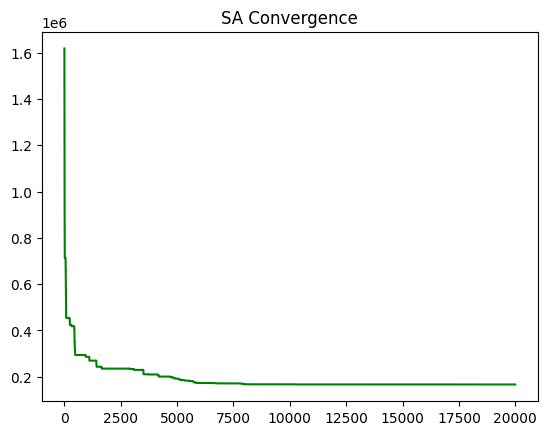

In [7]:
class MyList(list):
    pass

def create_individual():
    return MyList([build_gene(requests[r_id], DAYS) for r_id in requests])


# FITNESS
def fitness(individual):
    total_v_cost = 0
    total_v_dist = 0
    total_s_cost = 0
    total_s_dist = 0
    total_penalties = 0
    total_delay_penalties = 0

    vehicle_usage = set()
    vehicles_per_day = {}
    vehicle_plan = {}

    staff_usage = set()
    staff_work_days = {s_id: set() for s_id in staff} # [] => set()
    staff_plan = {}

    for id, gene in enumerate(individual):
        r_id = id + 1
        v_id, s_id, dd, svd = gene

        request = requests[r_id]
        medical_staff = staff[s_id]

        staff_plan.setdefault((svd, s_id), []).append(r_id)
        vehicle_plan.setdefault((dd, v_id), []).append(r_id)
        vehicles_per_day.setdefault(dd, set()).add(v_id)
        staff_work_days[s_id].add(svd) # NEW

        # 1. PENALTY: Although staff wil match requested speciality, but we will still add condition just in case
        if medical_staff[request['specialty_needed']] != 1:
            total_penalties += 20000
        
        # 2. PENALTY: Check if delivery day (dd) is within the delivery range otherwise penalty
        if dd > request['day_end']:
            days_to_penalise = dd - request['day_end']
            penalty = (days_to_penalise * supplies[request['supply_id']]['penalty_per_day'] * supplies[request['supply_id']]['criticality']) + 1000
            total_penalties += penalty
            total_delay_penalties += penalty

        # PENALTY: Delivery cannot happen before the start day
        if dd < request['day_start']:
            total_penalties += 15000
    
        # PENALTY: Staff can only visit after the supply has been delivered i.e. on same day or the next day.
        if svd < dd or svd > dd + 1:
            total_penalties += 15000
            total_delay_penalties += 15000
        if svd > request['day_end']:
            total_penalties += 16000
            total_delay_penalties += 16000


    daily_vehicle_costs = {}
    # VEHICLE ROUTING
    for (day, v_id), req_list in vehicle_plan.items():
        route = optimize_route(req_list=req_list, requests=requests)

        curr_v_load, curr_v_dist, curr_loc = 0, 0, 1
        vehicle_usage.add(v_id)

        for r_id in route:
            req = requests[r_id]
            loc_id = req['location_id']

            supply_load = supplies[req['supply_id']]['size'] * req['quantity']

            # calculate distance to X and from X back to Depot 1
            dist_to = distance(curr_loc, loc_id)

            #Exclude return distance
            # dist_back = distance(loc_id, 1)

            # if the load increases the capacity then return to depot
            if curr_v_load + supply_load > VEHICLE_CAPACITY:
                # Exclude MID Route return distance to depot 1
                # curr_v_dist += distance(curr_loc, 1)
                curr_v_load, curr_loc = 0, 1 # reset

                dist_to = distance(curr_loc, loc_id) # re calculate distance from 1 to target
                total_penalties += 30000
                # continue

            curr_v_dist += dist_to
            curr_v_load += supply_load
            curr_loc = loc_id

            # PENALTY: if single request exceeds the capacity
            if supply_load > VEHICLE_CAPACITY:
                total_penalties += 15000

        # Exclude distance for Depot
        # curr_v_dist += distance(curr_loc, 1)

        # PENALTY: daily distance limit
        if curr_v_dist > VEHICLE_MAX_DISTANCE:
            total_penalties += 15000

        # COST: VEHICLE COSTS
        v_standard_cost = VEHICLE_DAY_COST + (curr_v_dist * VEHICLE_DISTANCE_COST)
        daily_vehicle_costs[(day, v_id)] = v_standard_cost

        total_v_dist += curr_v_dist
        # COST: VEHICLE COSTS
        total_v_cost += v_standard_cost

    # COST/PENALTY: VEHICLE DAILY LIMIT PENALTY
    for day, vset in vehicles_per_day.items():
        if len(vset) > MAX_VEHICLES:
            v_list = list(vset)
            v_list.sort(key=lambda x: daily_vehicle_costs[(day, x)], reverse=True)

            extra_vehicles = len(vset) - MAX_VEHICLES
            for i in range(extra_vehicles):
                veh_id = v_list[i]
                total_v_cost += daily_vehicle_costs[(day, veh_id)]

    # COST: VEHICLE FIXED COST
    total_v_cost += (len(vehicle_usage) * VEHICLE_FIXED_COST)


    # STAFF ROUTING
    for (day, s_id), req_list in staff_plan.items():
        medical_staff = staff[s_id]
        home_loc = medical_staff["location_id"]

        curr_s_loc, curr_s_dist = home_loc, 0

        staff_usage.add(s_id)

        route = optimize_route(req_list, requests)

        # PENALTY: Staff should not exceed allowed patients visits per day
        if len(route) > medical_staff["max_patients_per_day"]:
            total_penalties += 40000

        for r_id in route:
            loc = requests[r_id]["location_id"]
            dist_to = distance(curr_s_loc, loc)
            curr_s_loc = loc

            curr_s_dist += dist_to

        # Staff returns to home location, calculate the distance
        # Excluding the return distance
        # dist_back = distance(curr_s_loc, home_loc)
        # curr_s_dist += dist_back


        # PENALTY: Staff should not exceed max distance per day
        if curr_s_dist > medical_staff['max_distance']:
            total_penalties += 15000

        total_s_dist += curr_s_dist
        # COST: Distance cost
        total_s_cost += STAFF_DAY_COST + (curr_s_dist * STAFF_DISTANCE_COST)

    # COST: Fixed cost for the active staff
    total_s_cost += (len(staff_usage) * STAFF_FIXED_COST)

    # PENALTY: Staff must not work on 6th day if they have been working for 5 days consecutively.
    for s_id, days in staff_work_days.items():
        sorted_days = sorted(list(days))
        streak = 1

        for i in range(1, len(sorted_days)):
            if sorted_days[i] == sorted_days[i-1] + 1:
                streak += 1
                if streak > 5:
                    total_penalties += 15000
            else:
                streak = 1

    total_cost = total_v_cost + total_s_cost + total_penalties 

    individual.metrics = {
        "vehicle_distance": total_v_dist,
        "vehicle_usage_days": vehicles_per_day,
        "vehicle_usage": vehicle_usage,
        "staff_distance": total_s_dist,
        "vehicle_cost": total_v_cost,
        "staff_cost": total_s_cost,
        "staff_usage": staff_usage,
        "staff_usage_days": staff_work_days,
        "penalties": total_penalties,
        "delay_penalties": total_delay_penalties,
        "total_cost": total_cost
    }

    return (total_cost,)

def get_smart_neighbor(individual):
    neighbor = copy.deepcopy(individual)
    idx = random.randrange(len(neighbor))
    v_id, s_id, dd, svd = neighbor[idx]
    r_id = idx + 1
    r = requests[r_id]
    
    choice = random.random()
    
    if choice < 0.30:
        # Move request to a clustered day (safer version)
        other_idx = random.randrange(len(neighbor))
        new_dd = neighbor[other_idx][2]
        new_svd = random.choice([new_dd, min(new_dd + 1, DAYS)])
        
        neighbor[idx] = (neighbor[other_idx][0], s_id, new_dd, new_svd)
        
    elif choice < 0.60:
        # Staff consolidation (safe)
        active_staff_on_day = [ind[1] for ind in neighbor if ind[3] == svd]
        possible_staff = [sid for sid in active_staff_on_day if staff[sid][r["specialty_needed"]] == 1]
        
        if possible_staff:
            new_sid = random.choice(possible_staff)
        else:
            valid_ids = list(get_staff_for_request(r_id, requests, staff).keys())
            new_sid = random.choice(valid_ids)
        
        neighbor[idx] = (v_id, new_sid, dd, svd)

    elif choice < 0.85:
        # Safe day shift
        new_dd = random.randint(r["day_start"], r["day_end"])
        new_svd = random.choice([new_dd, min(new_dd + 1, DAYS)])
        
        neighbor[idx] = (v_id, s_id, new_dd, new_svd)
        
    else:
        # LESS destructive swap (partial swap instead of full)
        idx2 = random.randrange(len(neighbor))
        
        v2, s2, dd2, svd2 = neighbor[idx2]
        
        # Swap only days (safer)
        neighbor[idx] = (v_id, s_id, dd2, random.choice([dd2, min(dd2 + 1, DAYS)]))
        neighbor[idx2] = (v2, s2, dd, random.choice([dd, min(dd + 1, DAYS)]))
        
    return neighbor

def simulated_annealing(run_id):
    random.seed()
    temp = 15000.0          # slightly reduced
    alpha = 0.999           # faster cooling
    min_temp = 1e-3
    iterations_per_temp = 20
    
    current_sol = create_individual()
    current_cost = fitness(current_sol)[0]
    best_sol = copy.deepcopy(current_sol)
    best_cost = current_cost
    
    history = []
    no_improvement = 0

    for step in range(20000):
        for _ in range(iterations_per_temp):
            neighbor = get_smart_neighbor(current_sol)
            neighbor_cost = fitness(neighbor)[0]
            
            delta = neighbor_cost - current_cost
            
            # ✅ SAFE acceptance
            if delta < 0:
                accept = True
            else:
                prob = math.exp(-delta / temp) if temp > 1e-8 else 0
                accept = random.random() < prob
            
            if accept:
                current_sol = neighbor
                current_cost = neighbor_cost
                
                if current_cost < best_cost:
                    best_sol = copy.deepcopy(current_sol)
                    best_cost = current_cost
                    no_improvement = 0
                else:
                    no_improvement += 1
            else:
                no_improvement += 1

        history.append(best_cost)

        # Cooling
        temp *= alpha

        # ✅ Early stopping
        if temp < min_temp:
            print("Temperature threshold reached.")
            break

        # ✅ Reheating (escape local minima)
        if no_improvement > 5000:
            temp = min(temp * 1.2, 10000)  # clamp to initial temp
            no_improvement = 0
            print(f"Reheating at step {step}, temp reset to {temp:.2f}")

        if step % 500 == 0:
            print(f"Step: {step} | Temp: {temp:.2f} | Best: {int(best_cost)}")

    return best_sol, history

if __name__ == "__main__":
    best_solution, cost_history = None, None
    all_time_lowest_cost = float('inf')

    try:
        multiprocessing.set_start_method('fork', force=True)
    except RuntimeError:
        pass
    
    with multiprocessing.Pool() as pool:
        print(f"Launching {NUM_RUNS} parallel SA runs...")
        results = pool.map(simulated_annealing, range(NUM_RUNS))
    
    for best_sol, hist in results:
        current_run_best_cost = fitness(best_sol)[0]

        if current_run_best_cost < all_time_lowest_cost:
            all_time_lowest_cost = current_run_best_cost
            best_solution = best_sol
            cost_history = hist

    convergence["SA"] = cost_history
    fitness(best_solution) 
    best_sa = best_solution
    print_solution(best_solution, requests, DAYS, "best_sa.txt")

    plt.plot(cost_history, color="green", label="Global Best Cost")
    plt.title('SA Convergence')
    plt.show()
    

In [3]:

best_gaa = [(1, 5, 2, 3), (3, 10, 2, 3), (2, 1, 5, 5), (3, 10, 4, 4), (3, 9, 1, 2), (2, 9, 4, 5), (2, 10, 5, 6), (2, 13, 6, 6), (3, 5, 9, 9), (3, 15, 7, 7), (2, 10, 2, 2), (3, 15, 2, 3), (3, 10, 4, 4), (3, 7, 9, 9), (3, 6, 8, 9), (3, 13, 9, 9), (2, 15, 11, 12), (3, 15, 9, 10), (3, 7, 12, 13), (1, 15, 13, 14), (1, 15, 13, 14), (1, 7, 15, 15), (1, 5, 17, 18), (1, 15, 19, 19), (3, 5, 3, 3), (2, 5, 4, 4), (2, 9, 5, 5), (1, 13, 7, 7), (3, 15, 7, 7), (2, 10, 8, 9), (2, 9, 11, 11), (1, 7, 11, 11), (3, 5, 13, 13), (1, 15, 13, 14), (3, 6, 13, 14), (1, 13, 15, 16), (2, 13, 16, 16), (2, 7, 16, 16), (1, 6, 17, 17), (1, 10, 19, 20), (3, 1, 1, 2), (1, 10, 2, 3), (3, 6, 4, 5), (2, 10, 5, 6), (3, 15, 7, 7), (2, 6, 6, 7), (1, 15, 7, 8), (3, 10, 9, 10), (2, 15, 9, 10), (1, 10, 11, 12), (2, 1, 11, 12), (3, 10, 12, 12), (1, 9, 13, 13), (1, 7, 15, 15), (1, 13, 17, 17), (2, 7, 16, 16), (2, 15, 19, 19), (2, 9, 19, 20), (2, 10, 2, 2), (3, 15, 2, 3)]
best_nsgaa = [(1, 5, 2, 2), (2, 10, 3, 4), (3, 15, 4, 4), (2, 10, 3, 3), (3, 11, 2, 2), (2, 6, 6, 6), (2, 7, 5, 6), (2, 7, 5, 5), (5, 1, 9, 9), (4, 15, 7, 8), (2, 10, 1, 1), (2, 7, 5, 6), (1, 10, 7, 7), (5, 7, 7, 7), (3, 15, 8, 9), (3, 10, 10, 10), (3, 5, 12, 12), (3, 15, 10, 10), (2, 7, 10, 11), (2, 9, 12, 12), (2, 15, 15, 15), (2, 2, 16, 17), (3, 5, 16, 16), (5, 15, 15, 16), (3, 5, 4, 5), (4, 5, 6, 6), (4, 15, 6, 6), (2, 2, 6, 6), (4, 9, 7, 8), (2, 10, 9, 10), (1, 9, 9, 9), (3, 7, 10, 11), (2, 1, 12, 13), (4, 15, 14, 14), (3, 6, 13, 13), (3, 5, 16, 16), (2, 15, 16, 16), (3, 7, 16, 17), (1, 2, 18, 18), (1, 10, 18, 18), (2, 11, 2, 2), (3, 10, 4, 4), (2, 7, 5, 5), (2, 7, 5, 6), (4, 2, 6, 7), (5, 6, 7, 7), (2, 15, 9, 9), (1, 5, 9, 10), (3, 11, 10, 11), (5, 10, 10, 11), (3, 1, 12, 12), (3, 1, 13, 14), (4, 9, 14, 15), (3, 7, 16, 16), (2, 6, 15, 16), (1, 7, 18, 18), (5, 1, 18, 18), (5, 15, 18, 19), (2, 10, 1, 1), (3, 7, 2, 2)]
# best_acoo = [(2, 5, 1, 2), (2, 10, 3, 4), (3, 9, 3, 4), (2, 10, 3, 3), (1, 9, 1, 2), (1, 15, 4, 4), (4, 13, 6, 7), (2, 10, 6, 6), (5, 5, 7, 7), (2, 9, 7, 7), (2, 7, 1, 2), (3, 15, 3, 4), (2, 10, 6, 7), (4, 13, 6, 6), (1, 5, 8, 8), (5, 10, 7, 8), (1, 1, 9, 10), (3, 15, 12, 13), (5, 9, 10, 10), (3, 9, 13, 14), (3, 1, 13, 13), (5, 13, 14, 15), (1, 15, 16, 17), (3, 15, 17, 18), (4, 15, 3, 3), (1, 10, 4, 4), (1, 15, 6, 7), (2, 7, 6, 6), (2, 9, 7, 8), (4, 7, 9, 10), (1, 7, 9, 9), (5, 7, 10, 11), (3, 5, 12, 12), (3, 9, 13, 13), (2, 7, 15, 15), (3, 7, 16, 16), (2, 7, 15, 15), (1, 9, 16, 17), (3, 7, 17, 18), (3, 10, 18, 19), (1, 9, 1, 1), (1, 15, 2, 3), (3, 7, 3, 4), (4, 1, 6, 6), (1, 1, 6, 6), (5, 7, 7, 8), (4, 15, 9, 9), (1, 15, 8, 9), (5, 15, 9, 9), (3, 10, 12, 12), (3, 15, 13, 13), (5, 5, 14, 14), (3, 15, 13, 14), (5, 1, 14, 15), (3, 9, 16, 17), (1, 7, 16, 17), (3, 15, 18, 18), (3, 9, 18, 19), (2, 7, 1, 2), (3, 5, 3, 4)]
best_saa = [(1, 7, 1, 1), (1, 15, 4, 4), (3, 15, 5, 5), (3, 7, 4, 4), (3, 7, 1, 1), (1, 15, 5, 6), (3, 7, 5, 5), (1, 7, 6, 6), (1, 15, 6, 6), (3, 15, 8, 8), (1, 7, 1, 2), (1, 15, 6, 6), (3, 7, 4, 4), (1, 7, 5, 6), (1, 7, 8, 8), (1, 7, 9, 10), (3, 15, 8, 8), (1, 15, 11, 11), (1, 7, 12, 12), (3, 15, 13, 14), (3, 15, 13, 13), (1, 7, 13, 13), (1, 15, 18, 18), (1, 15, 16, 17), (3, 7, 4, 4), (1, 15, 4, 4), (3, 15, 5, 5), (1, 7, 8, 8), (3, 15, 8, 8), (1, 7, 9, 10), (1, 15, 10, 10), (1, 7, 10, 11), (1, 15, 11, 12), (3, 15, 13, 14), (1, 7, 13, 14), (1, 7, 16, 16), (1, 7, 16, 16), (3, 7, 17, 17), (3, 15, 17, 18), (1, 15, 18, 18), (3, 7, 1, 1), (3, 15, 3, 4), (1, 7, 5, 5), (3, 7, 5, 5), (3, 15, 5, 5), (1, 7, 6, 7), (1, 7, 8, 8), (1, 7, 10, 10), (1, 15, 10, 11), (1, 15, 11, 12), (3, 15, 13, 13), (1, 15, 12, 12), (3, 15, 13, 14), (1, 7, 16, 16), (1, 7, 17, 17), (3, 7, 17, 17), (1, 15, 17, 17), (1, 15, 18, 19), (1, 7, 1, 2), (3, 7, 2, 2)]

class MyList(list):
    pass

best_ga = MyList(best_gaa)
best_nsga = MyList(best_nsgaa)
# best_aco = MyList(best_acoo)
best_sa = MyList(best_saa)

fitness(best_ga)
fitness(best_nsga)
# fitness(best_aco)
fitness(best_sa)

166711.01374817983

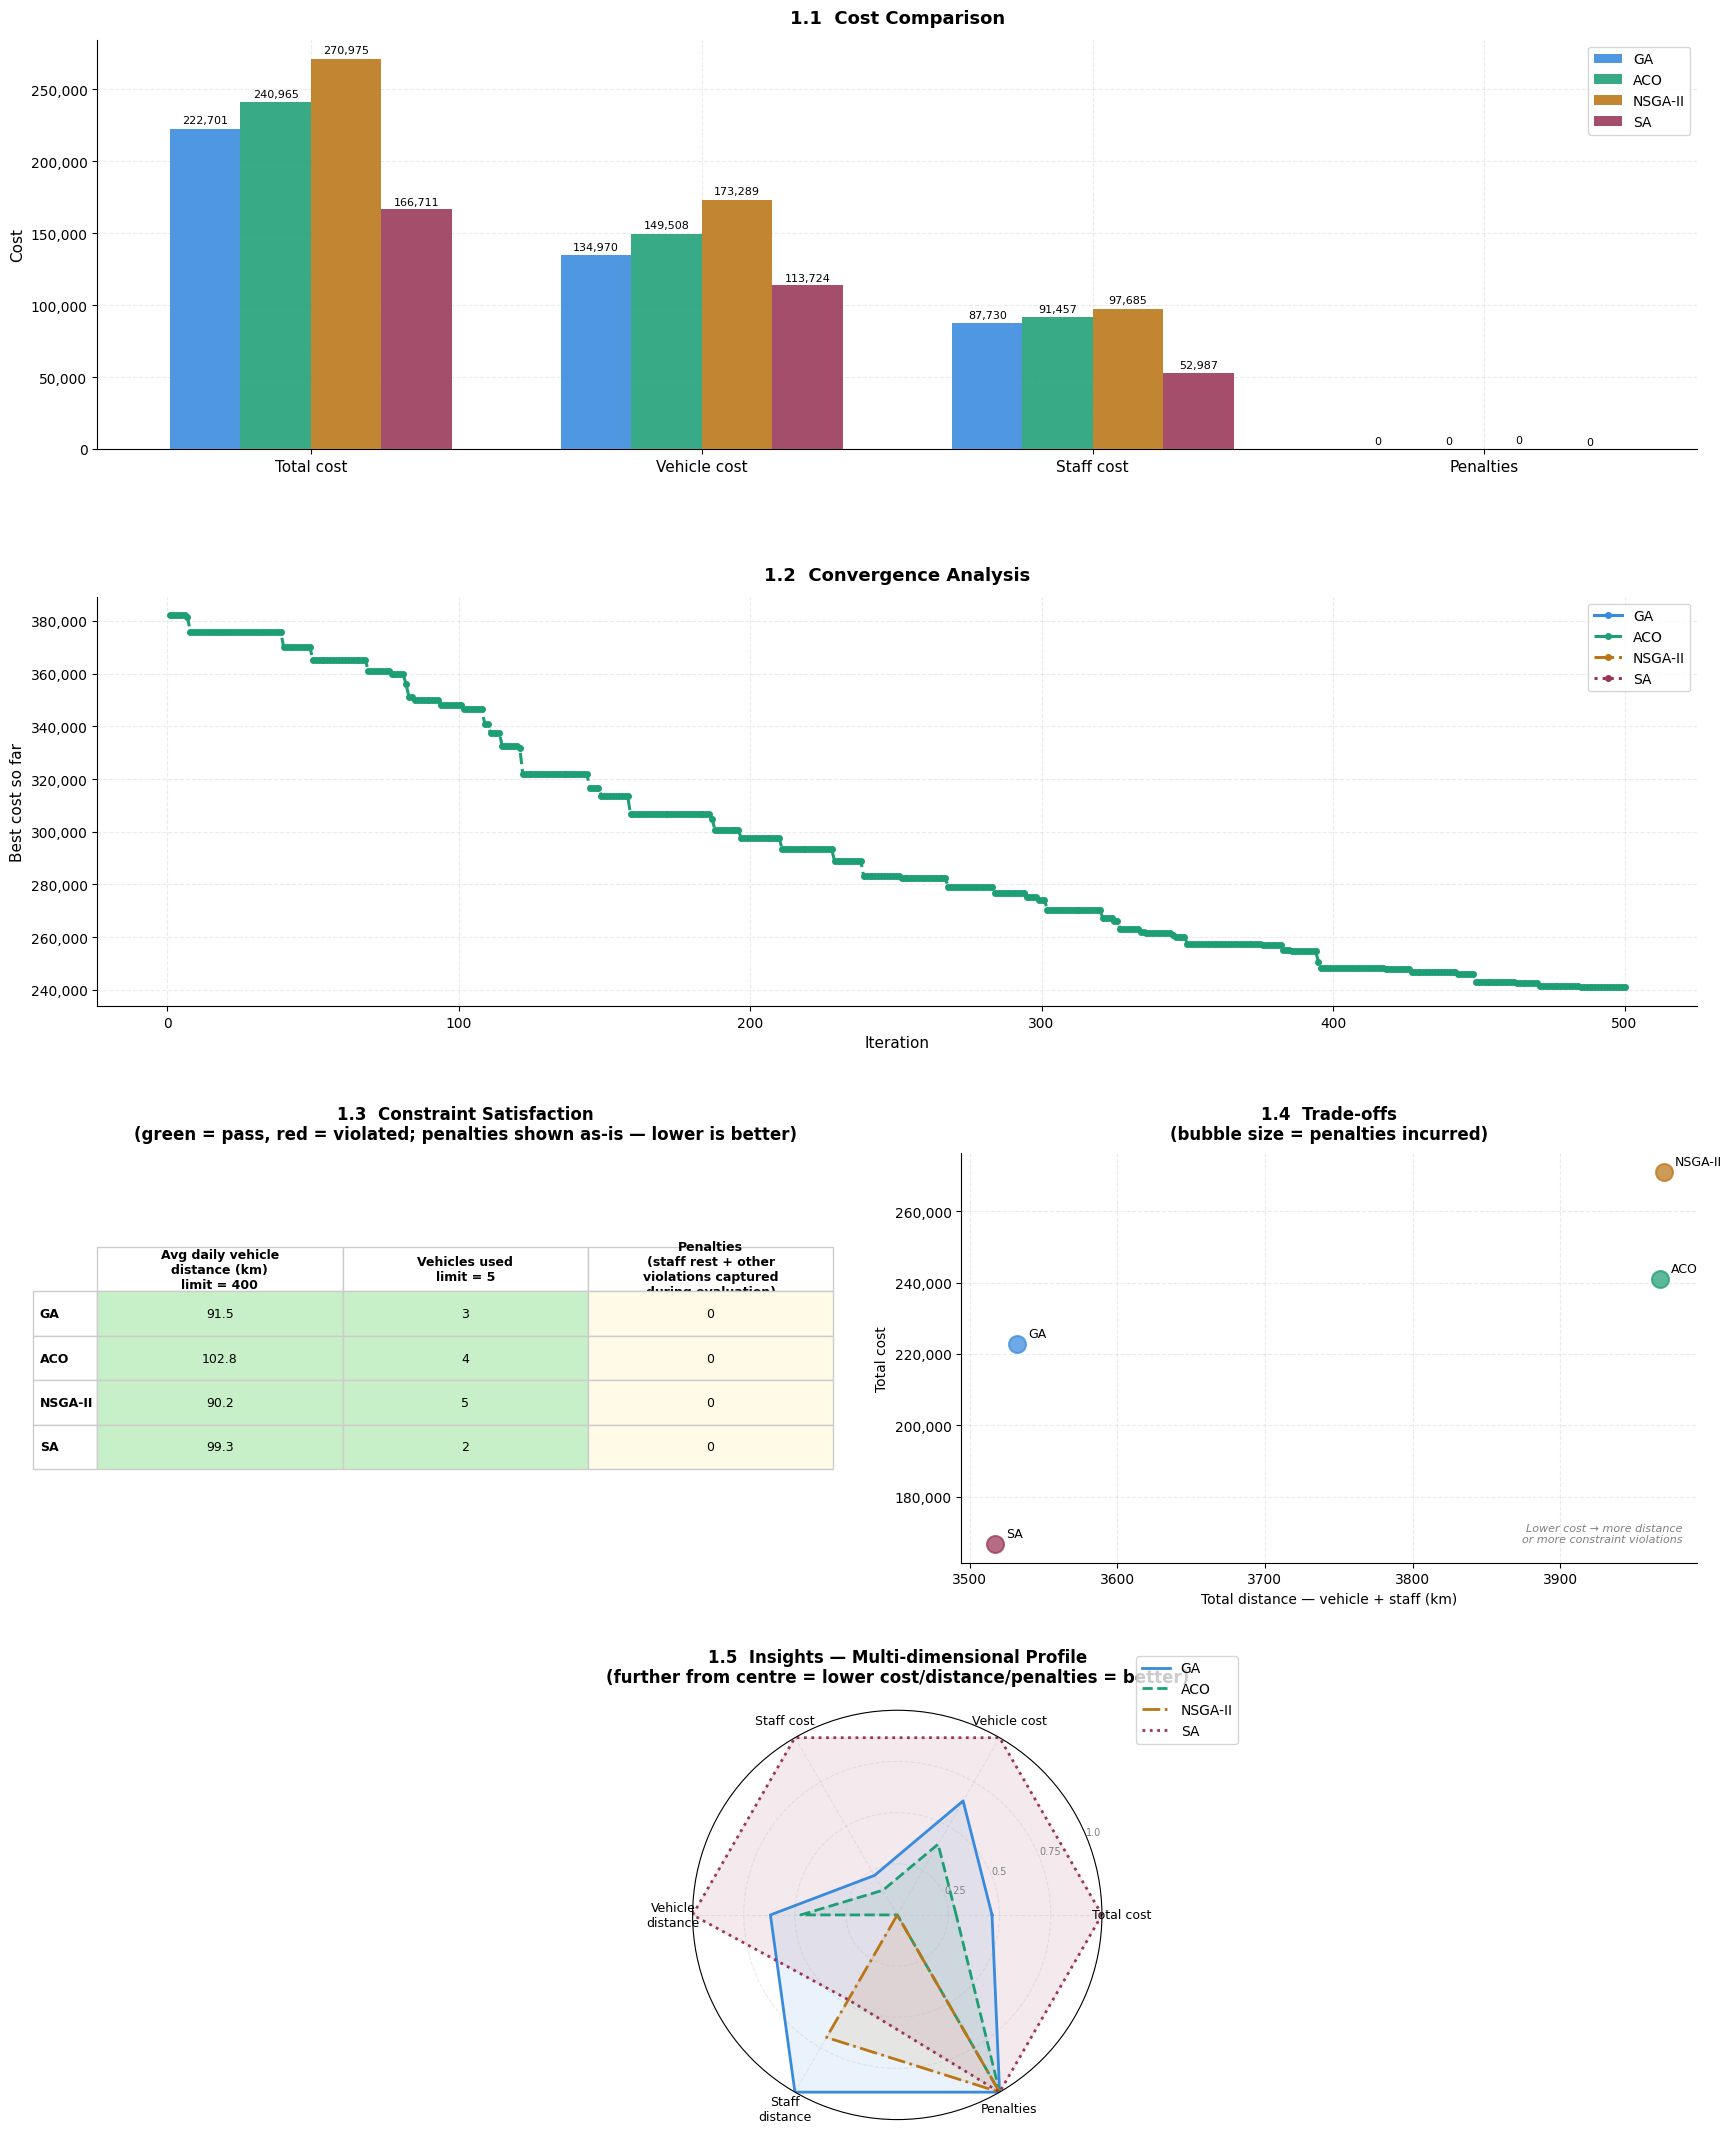

Saved → algorithm_analysis.png


In [4]:
import matplotlib.pyplot as plt
import numpy as np

metrics = {
    "GA":   best_ga.metrics,
    "ACO":  best_aco.metrics,
    "NSGA-II": best_nsga.metrics,
    "SA":   best_sa.metrics,
}

# ════════════════════════════════════════════════════════════

ALGOS      = list(metrics.keys())
COLORS     = ["#378ADD", "#1D9E75", "#BA7517", "#993556"]
ALGO_COLOR = dict(zip(ALGOS, COLORS))
LINESTYLES = ["-", "--", "-.", ":"]

plt.rcParams.update({
    "font.family":       "DejaVu Sans",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.alpha":        0.25,
    "grid.linestyle":    "--",
})

fig = plt.figure(figsize=(18, 22))
fig.patch.set_facecolor("white")


# ── 1.1  COST COMPARISON ─────────────────────────────────────────────────────
ax1 = fig.add_subplot(4, 2, (1, 2))

cost_keys   = ["total_cost", "vehicle_cost", "staff_cost", "penalties"]
cost_labels = ["Total cost", "Vehicle cost", "Staff cost", "Penalties"]
x     = np.arange(len(cost_labels))
bar_w = 0.18

for i, algo in enumerate(ALGOS):
    vals = [metrics[algo][k] for k in cost_keys]
    bars = ax1.bar(x + i * bar_w, vals, bar_w, label=algo,
                   color=ALGO_COLOR[algo], alpha=0.88, zorder=3)
    for bar, v in zip(bars, vals):
        ax1.text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + max(vals) * 0.01,
                 f"{v:,.0f}", ha="center", va="bottom", fontsize=8)

ax1.set_xticks(x + bar_w * 1.5)
ax1.set_xticklabels(cost_labels, fontsize=11)
ax1.set_ylabel("Cost", fontsize=11)
ax1.set_title("1.1  Cost Comparison", fontsize=13, fontweight="bold", pad=12)
ax1.legend(loc="upper right", fontsize=10)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:,.0f}"))


# ── 1.2  CONVERGENCE ─────────────────────────────────────────────────────────
ax2 = fig.add_subplot(4, 2, (3, 4))

for (algo, history), ls in zip(convergence.items(), LINESTYLES):
    iters = range(1, len(history) + 1)
    ax2.plot(iters, history, label=algo, color=ALGO_COLOR[algo],
             linewidth=2.2, linestyle=ls, marker="o", markersize=4, zorder=3)

ax2.set_xlabel("Iteration", fontsize=11)
ax2.set_ylabel("Best cost so far", fontsize=11)
ax2.set_title("1.2  Convergence Analysis", fontsize=13, fontweight="bold", pad=12)
ax2.legend(loc="upper right", fontsize=10)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:,.0f}"))


# CONSTRAINT SATISFACTION ─────────────────────────────────────────────

ax3 = fig.add_subplot(4, 2, 5)


def get_scalar(val, fallback=1):
    """Handle metrics that may be a dict or a plain number."""
    if isinstance(val, dict):
        # Use a generator to get the length of each set/value
        return sum(len(v) if isinstance(v, (set, list, dict)) else v for v in val.values())
    return val if val else fallback

rows = []
for algo in ALGOS:
    m = metrics[algo]

    active_vdays  = get_scalar(m["vehicle_usage_days"])
    avg_daily     = m["vehicle_distance"] / max(active_vdays, 1)
    vdist_ok      = avg_daily <= VEHICLE_MAX_DISTANCE

    if isinstance(m["vehicle_usage"], dict):
        vehicles_used = sum(1 for used in m["vehicle_usage"].values() if used)
    elif isinstance(m["vehicle_usage"], (set, list)):
        vehicles_used = len(m["vehicle_usage"])
    else:
        # Use fallback 0 if it's None/Empty before calling int()
        vehicles_used = int(m["vehicle_usage"] or 0)

    vcount_ok = vehicles_used <= MAX_VEHICLES
    
    penalty_val = m["penalties"]

    rows.append({
        "algo":        algo,
        "avg_vdist":   avg_daily,
        "vdist_ok":    vdist_ok,
        "vehicles":    vehicles_used,
        "vcount_ok":   vcount_ok,
        "penalties":   penalty_val,
    })

col_labels = [
    f"Avg daily vehicle\ndistance (km)\nlimit = {VEHICLE_MAX_DISTANCE}",
    f"Vehicles used\nlimit = {MAX_VEHICLES}",
    f"Penalties\n(staff rest + other\nviolations captured\nduring evaluation)",
]

cell_text   = []
cell_colors = []

for row in rows:
    cell_text.append([
        f"{row['avg_vdist']:.1f}",
        str(row["vehicles"]),
        f"{row['penalties']:,.0f}",
    ])
    cell_colors.append([
        "#c8f0c8" if row["vdist_ok"]  else "#f5c6c6",
        "#c8f0c8" if row["vcount_ok"] else "#f5c6c6",
        "#fffbe6",   # penalties are informational — amber-neutral
    ])

ax3.axis("off")
tbl = ax3.table(
    cellText=cell_text,
    rowLabels=ALGOS,
    colLabels=col_labels,
    cellColours=cell_colors,
    cellLoc="center",
    loc="center",
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1, 2.4)

for (r, c), cell in tbl.get_celld().items():
    cell.set_edgecolor("#cccccc")
    if r == 0 or c == -1:
        cell.set_text_props(fontweight="bold")

ax3.set_title(
    "1.3  Constraint Satisfaction\n"
    "(green = pass, red = violated; penalties shown as-is — lower is better)",
    fontsize=12, fontweight="bold", pad=10,
)


# ── 1.4  TRADE-OFFS: cost vs total distance, bubble size = penalties ──────────
ax4 = fig.add_subplot(4, 2, 6)

max_pen = max(metrics[a]["penalties"] for a in ALGOS) or 1
for algo in ALGOS:
    m = metrics[algo]
    total_dist = m["vehicle_distance"] + m["staff_distance"]
    size = 150 + (m["penalties"] / max_pen) * 600
    ax4.scatter(total_dist, m["total_cost"], s=size,
                color=ALGO_COLOR[algo], alpha=0.72,
                edgecolors=ALGO_COLOR[algo], linewidths=1.5, zorder=3)
    ax4.annotate(algo, (total_dist, m["total_cost"]),
                 textcoords="offset points", xytext=(8, 5), fontsize=9)

ax4.set_xlabel("Total distance — vehicle + staff (km)", fontsize=10)
ax4.set_ylabel("Total cost", fontsize=10)
ax4.set_title(
    "1.4  Trade-offs\n(bubble size = penalties incurred)",
    fontsize=12, fontweight="bold", pad=10,
)
ax4.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:,.0f}"))
ax4.text(0.98, 0.05,
         "Lower cost → more distance\nor more constraint violations",
         transform=ax4.transAxes, ha="right", fontsize=8,
         color="gray", style="italic")


# ── 1.5  INSIGHTS — RADAR CHART ──────────────────────────────────────────────
ax5 = fig.add_subplot(4, 2, (7, 8), polar=True)

radar_keys   = ["total_cost", "vehicle_cost", "staff_cost",
                "vehicle_distance", "staff_distance", "penalties"]
radar_labels = ["Total cost", "Vehicle cost", "Staff cost",
                "Vehicle\ndistance", "Staff\ndistance", "Penalties"]
N      = len(radar_labels)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

def normalize_invert(vals):
    """Lower raw value → higher radar score (lower = better for all dims here)."""
    mn, mx = min(vals), max(vals)
    if mx == mn:
        return [1.0] * len(vals)
    return [(mx - v) / (mx - mn) for v in vals]

all_raw     = {k: [metrics[a][k] for a in ALGOS] for k in radar_keys}
algo_scores = {
    algo: [normalize_invert(all_raw[k])[ALGOS.index(algo)] for k in radar_keys]
    for algo in ALGOS
}

for algo, ls in zip(ALGOS, LINESTYLES):
    vals = algo_scores[algo] + algo_scores[algo][:1]
    ax5.plot(angles, vals, color=ALGO_COLOR[algo], linewidth=2,
             linestyle=ls, label=algo)
    ax5.fill(angles, vals, color=ALGO_COLOR[algo], alpha=0.10)

ax5.set_thetagrids(np.degrees(angles[:-1]), radar_labels, fontsize=9)
ax5.set_ylim(0, 1)
ax5.set_yticks([0.25, 0.5, 0.75, 1.0])
ax5.set_yticklabels(["0.25", "0.5", "0.75", "1.0"], fontsize=7, color="gray")
ax5.set_title(
    "1.5  Insights — Multi-dimensional Profile\n"
    "(further from centre = lower cost/distance/penalties = better)",
    fontsize=12, fontweight="bold", pad=20,
)
ax5.legend(loc="upper right", bbox_to_anchor=(1.35, 1.15), fontsize=10)


plt.tight_layout(pad=3.0)
plt.savefig("algorithm_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → algorithm_analysis.png")